<a href="https://www.kaggle.com/code/lalit7881/e-commerce-sales-predictione-commerce-sales?scriptVersionId=307144145" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/algozee/multi-source-data-for-e-commerce-sales-prediction/global_ecommerce_forecasting.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/algozee/multi-source-data-for-e-commerce-sales-prediction/global_ecommerce_forecasting.csv")

In [3]:
df.head()

,order_datetime,year,month,week_of_year,day_of_week,order_hour,is_weekend,country,country_code,product_id,customer_id,unit_price_gbp,quantity_sold,sales_amount_gbp,population_total,gdp_current_usd,gdp_growth_pct,inflation_consumer_pct
0,2009-12-01 07:45:00,2009,12,49,1,7,0,United Kingdom,GBR,21523,13085,5.95,10,59.50,62276270.0,2.412840e+12,-17.633976,1.89709
1,2009-12-01 07:45:00,2009,12,49,1,7,0,United Kingdom,GBR,79323W,13085,6.75,12,81.00,62276270.0,2.412840e+12,-17.633976,1.89709
2,2009-12-01 09:06:00,2009,12,49,1,9,0,United Kingdom,GBR,82582,13078,2.10,12,25.20,62276270.0,2.412840e+12,-17.633976,1.89709
3,2009-12-01 09:06:00,2009,12,49,1,9,0,United Kingdom,GBR,22111,13078,4.25,24,102.00,62276270.0,2.412840e+12,-17.633976,1.89709
4,2009-12-01 09:06:00,2009,12,49,1,9,0,United Kingdom,GBR,21756,13078,5.95,3,17.85,62276270.0,2.412840e+12,-17.633976,1.89709


In [4]:
df.tail()

,order_datetime,year,month,week_of_year,day_of_week,order_hour,is_weekend,country,country_code,product_id,customer_id,unit_price_gbp,quantity_sold,sales_amount_gbp,population_total,gdp_current_usd,gdp_growth_pct,inflation_consumer_pct
99995,2010-12-09 20:01:00,2010,12,49,3,20,0,United Kingdom,GBR,22751,17530,3.75,1,3.75,62766365.0,2.485483e+12,3.010668,1.589081
99996,2010-12-09 20:01:00,2010,12,49,3,20,0,United Kingdom,GBR,21931,17530,1.95,2,3.90,62766365.0,2.485483e+12,3.010668,1.589081
99997,2010-12-09 20:01:00,2010,12,49,3,20,0,United Kingdom,GBR,21034,17530,0.95,1,0.95,62766365.0,2.485483e+12,3.010668,1.589081
99998,2010-12-09 20:01:00,2010,12,49,3,20,0,United Kingdom,GBR,22367,17530,1.95,4,7.80,62766365.0,2.485483e+12,3.010668,1.589081
99999,2010-12-09 20:01:00,2010,12,49,3,20,0,United Kingdom,GBR,21592,17530,1.25,4,5.00,62766365.0,2.485483e+12,3.010668,1.589081


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_datetime          100000 non-null  object 
 1   year                    100000 non-null  int64  
 2   month                   100000 non-null  int64  
 3   week_of_year            100000 non-null  int64  
 4   day_of_week             100000 non-null  int64  
 5   order_hour              100000 non-null  int64  
 6   is_weekend              100000 non-null  int64  
 7   country                 100000 non-null  object 
 8   country_code            100000 non-null  object 
 9   product_id              100000 non-null  object 
 10  customer_id             100000 non-null  int64  
 11  unit_price_gbp          100000 non-null  float64
 12  quantity_sold           100000 non-null  int64  
 13  sales_amount_gbp        100000 non-null  float64
 14  population_total     

In [6]:
df.describe()

,year,month,week_of_year,day_of_week,order_hour,is_weekend,customer_id,unit_price_gbp,quantity_sold,sales_amount_gbp,population_total,gdp_current_usd,gdp_growth_pct,inflation_consumer_pct
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,1.000000e+05,1.000000e+05,100000.000000,100000.000000
mean,2009.929280,7.377590,29.915140,2.583280,12.680470,0.153960,14768.12664,3.889158,18.657790,26.948917,5.409812e+07,2.161193e+12,0.462626,1.104250
std,0.256358,3.456657,15.003269,1.923159,2.351588,0.360912,1799.16475,59.750204,159.346502,92.390214,2.664448e+07,1.115049e+12,6.134116,1.655513
min,2009.000000,1.000000,1.000000,0.000000,7.000000,0.000000,12346.00000,0.001000,1.000000,0.001000,3.180410e+05,9.035824e+09,-19.629870,-15.182980
25%,2010.000000,4.000000,17.000000,1.000000,11.000000,0.000000,12926.00000,1.250000,2.000000,6.600000,6.227627e+07,2.412840e+12,-2.062266,1.089446
50%,2010.000000,8.000000,33.000000,2.000000,13.000000,0.000000,14646.00000,1.950000,6.000000,14.980000,6.276636e+07,2.485483e+12,3.010668,1.589081
75%,2010.000000,10.000000,43.000000,4.000000,14.000000,0.000000,16279.00000,3.750000,12.000000,20.400000,6.276636e+07,2.485483e+12,3.010668,1.589081
max,2010.000000,12.000000,52.000000,6.000000,20.000000,1.000000,18287.00000,10953.500000,19152.000000,10953.500000,3.093782e+08,1.504897e+13,32.504047,16.527886


In [7]:
df.isnull().sum()

order_datetime            0
year                      0
month                     0
week_of_year              0
day_of_week               0
order_hour                0
is_weekend                0
country                   0
country_code              0
product_id                0
customer_id               0
unit_price_gbp            0
quantity_sold             0
sales_amount_gbp          0
population_total          0
gdp_current_usd           0
gdp_growth_pct            0
inflation_consumer_pct    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(255)

In [9]:
df.dtypes

order_datetime             object
year                        int64
month                       int64
week_of_year                int64
day_of_week                 int64
order_hour                  int64
is_weekend                  int64
country                    object
country_code               object
product_id                 object
customer_id                 int64
unit_price_gbp            float64
quantity_sold               int64
sales_amount_gbp          float64
population_total          float64
gdp_current_usd           float64
gdp_growth_pct            float64
inflation_consumer_pct    float64
dtype: object

In [10]:
df.shape

(100000, 18)

In [11]:
df.columns

Index(['order_datetime', 'year', 'month', 'week_of_year', 'day_of_week',
       'order_hour', 'is_weekend', 'country', 'country_code', 'product_id',
       'customer_id', 'unit_price_gbp', 'quantity_sold', 'sales_amount_gbp',
       'population_total', 'gdp_current_usd', 'gdp_growth_pct',
       'inflation_consumer_pct'],
      dtype='object')

In [12]:
df.nunique()

order_datetime            14903
year                          2
month                        12
week_of_year                 52
day_of_week                   7
order_hour                   14
is_weekend                    2
country                      34
country_code                 34
product_id                 3623
customer_id                4012
unit_price_gbp              300
quantity_sold               232
sales_amount_gbp           1541
population_total             55
gdp_current_usd              55
gdp_growth_pct               55
inflation_consumer_pct       55
dtype: int64

## EDA

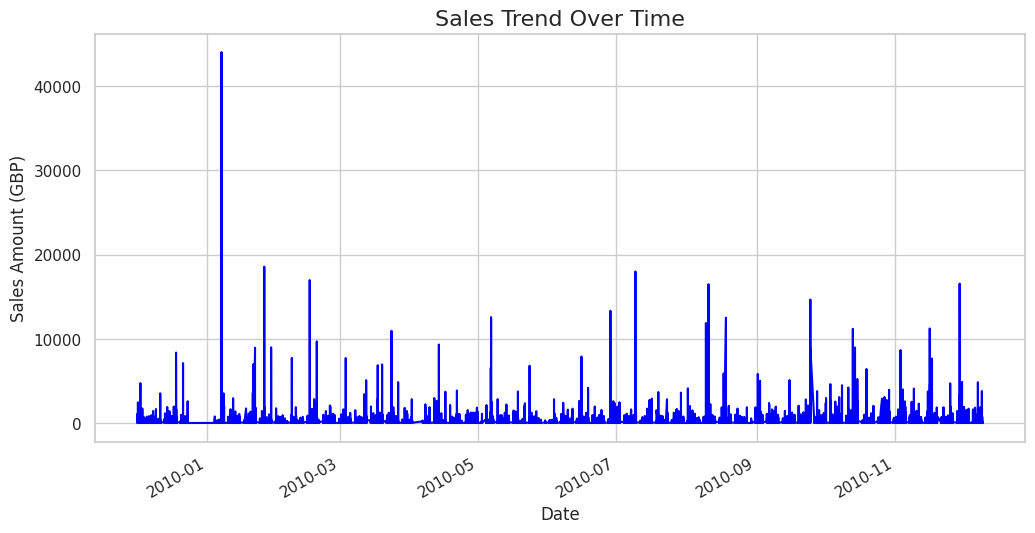

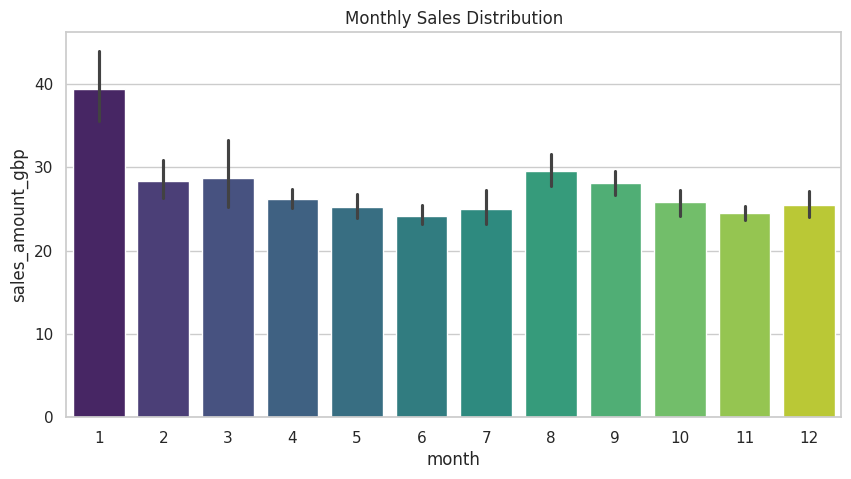

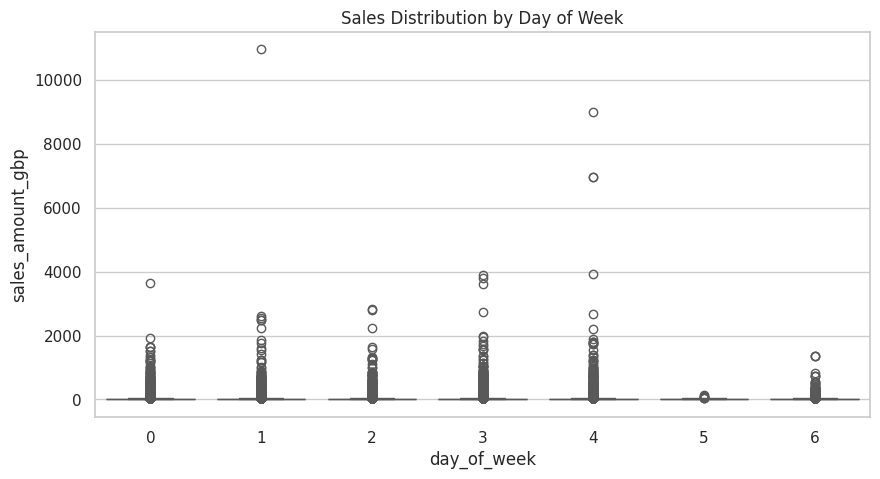

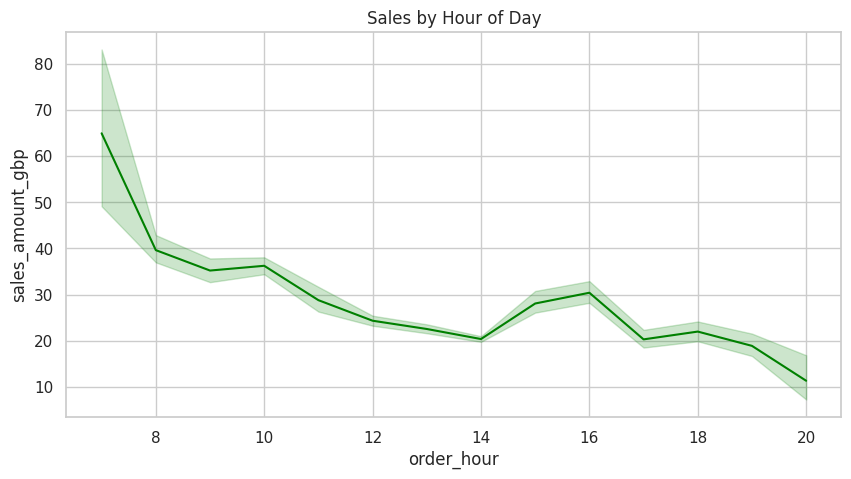

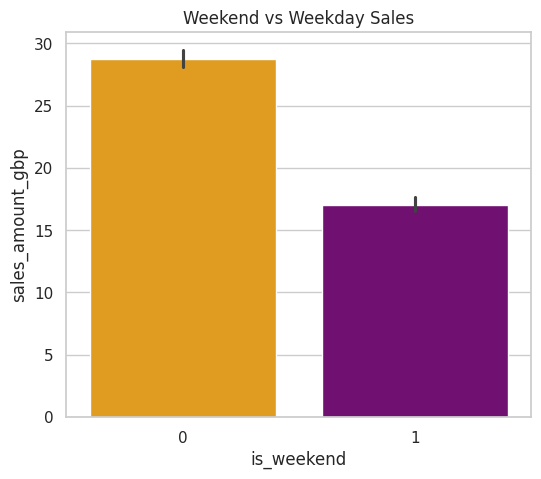

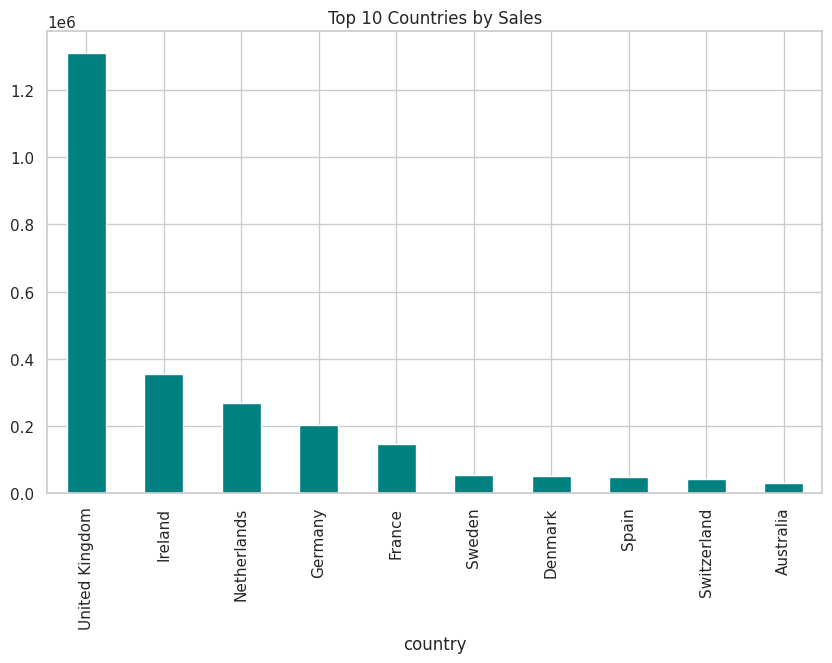

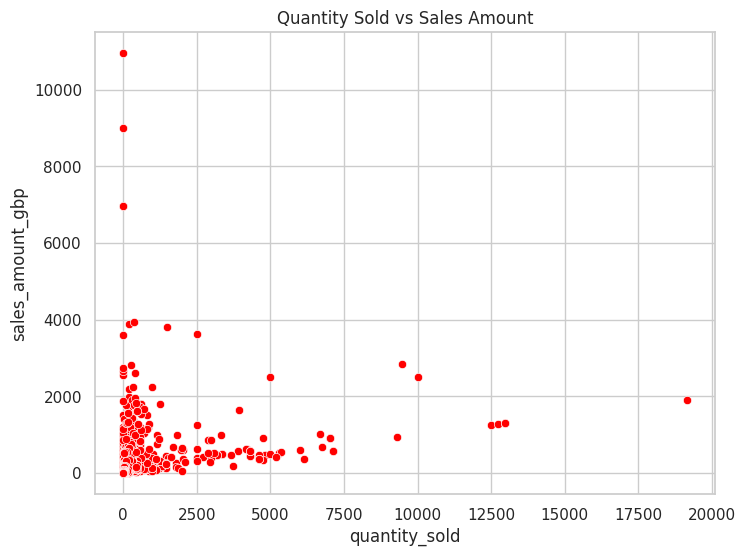

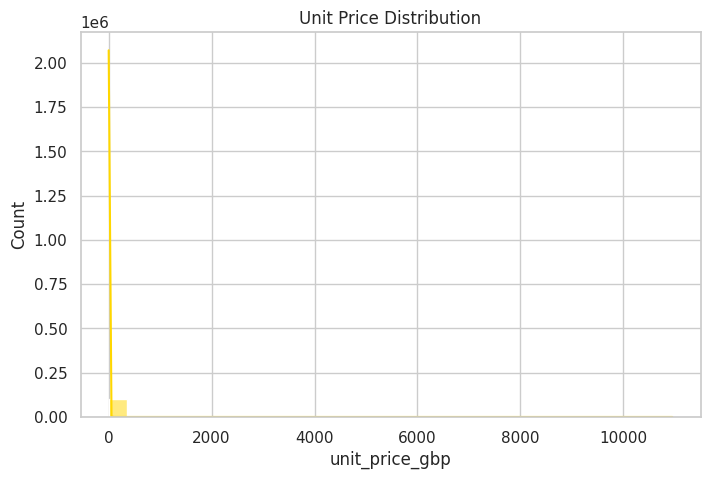

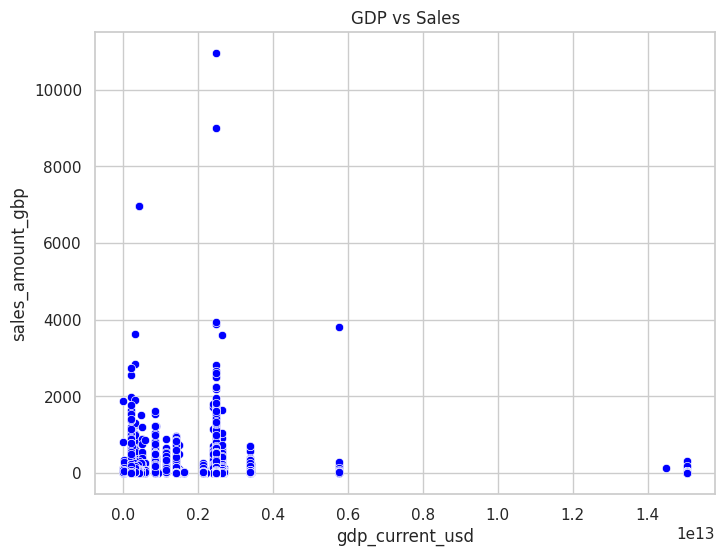

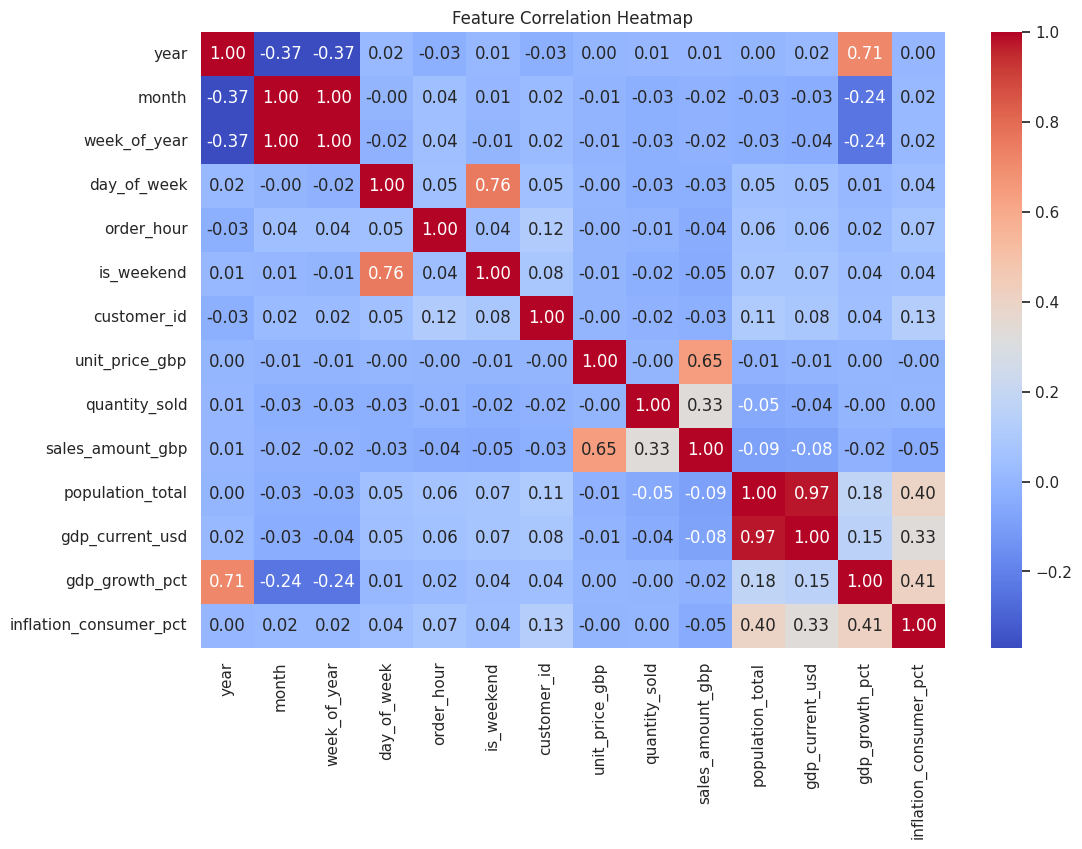

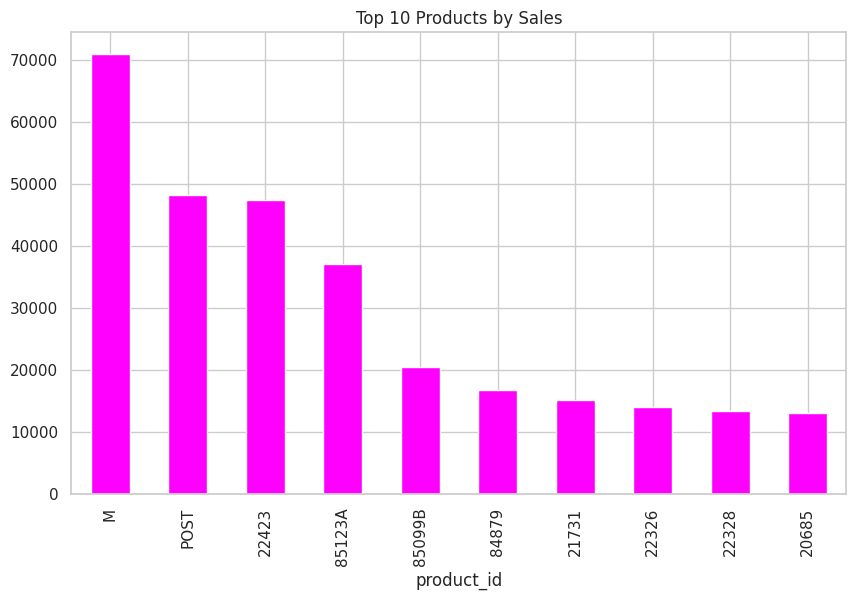

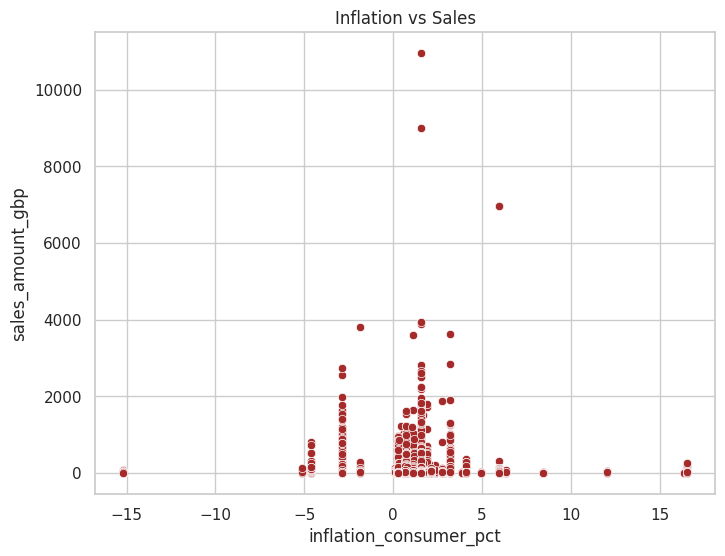

In [13]:
# Convert datetime
df['order_datetime'] = pd.to_datetime(df['order_datetime'])

# Style
sns.set(style="whitegrid")

# -------------------------------
# 1. Sales Trend Over Time
# -------------------------------
plt.figure(figsize=(12,6))
df.groupby('order_datetime')['sales_amount_gbp'].sum().plot(color='blue')
plt.title("Sales Trend Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sales Amount (GBP)")
plt.show()

# -------------------------------
# 2. Monthly Sales Distribution
# -------------------------------
plt.figure(figsize=(10,5))
sns.barplot(x='month', y='sales_amount_gbp', data=df, palette='viridis')
plt.title("Monthly Sales Distribution")
plt.show()

# -------------------------------
# 3. Sales by Day of Week
# -------------------------------
plt.figure(figsize=(10,5))
sns.boxplot(x='day_of_week', y='sales_amount_gbp', data=df, palette='coolwarm')
plt.title("Sales Distribution by Day of Week")
plt.show()

# -------------------------------
# 4. Hourly Sales Pattern
# -------------------------------
plt.figure(figsize=(10,5))
sns.lineplot(x='order_hour', y='sales_amount_gbp', data=df, color='green')
plt.title("Sales by Hour of Day")
plt.show()

# -------------------------------
# 5. Weekend vs Weekday Sales
# -------------------------------
plt.figure(figsize=(6,5))
sns.barplot(x='is_weekend', y='sales_amount_gbp', data=df, palette=['orange','purple'])
plt.title("Weekend vs Weekday Sales")
plt.show()

# -------------------------------
# 6. Top Countries by Sales
# -------------------------------
top_countries = df.groupby('country')['sales_amount_gbp'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_countries.plot(kind='bar', color='teal')
plt.title("Top 10 Countries by Sales")
plt.show()

# -------------------------------
# 7. Quantity vs Sales Scatter
# -------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x='quantity_sold', y='sales_amount_gbp', data=df, color='red')
plt.title("Quantity Sold vs Sales Amount")
plt.show()

# -------------------------------
# 8. Price Distribution
# -------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['unit_price_gbp'], bins=30, kde=True, color='gold')
plt.title("Unit Price Distribution")
plt.show()

# -------------------------------
# 9. GDP vs Sales (Economic Insight)
# -------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x='gdp_current_usd', y='sales_amount_gbp', data=df, color='blue')
plt.title("GDP vs Sales")
plt.show()

# -------------------------------
# 10. Correlation Heatmap
# -------------------------------
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=['float64', 'int64']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# -------------------------------
# 11. Top Products
# -------------------------------
top_products = df.groupby('product_id')['sales_amount_gbp'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='bar', color='magenta')
plt.title("Top 10 Products by Sales")
plt.show()

# -------------------------------
# 12. Inflation vs Sales
# -------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x='inflation_consumer_pct', y='sales_amount_gbp', data=df, color='brown')
plt.title("Inflation vs Sales")
plt.show()

## Feature Engieering


Logistic Regression
Accuracy: 0.9265
ROC AUC: 0.9761132766829383
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     10039
           1       0.93      0.92      0.93      9961

    accuracy                           0.93     20000
   macro avg       0.93      0.93      0.93     20000
weighted avg       0.93      0.93      0.93     20000


Decision Tree
Accuracy: 0.99945
ROC AUC: 0.9994505766432707
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10039
           1       1.00      1.00      1.00      9961

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000


Random Forest
Accuracy: 0.97775
ROC AUC: 0.9980969010538651
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     10039
           1       0.97      0.98      0.98      

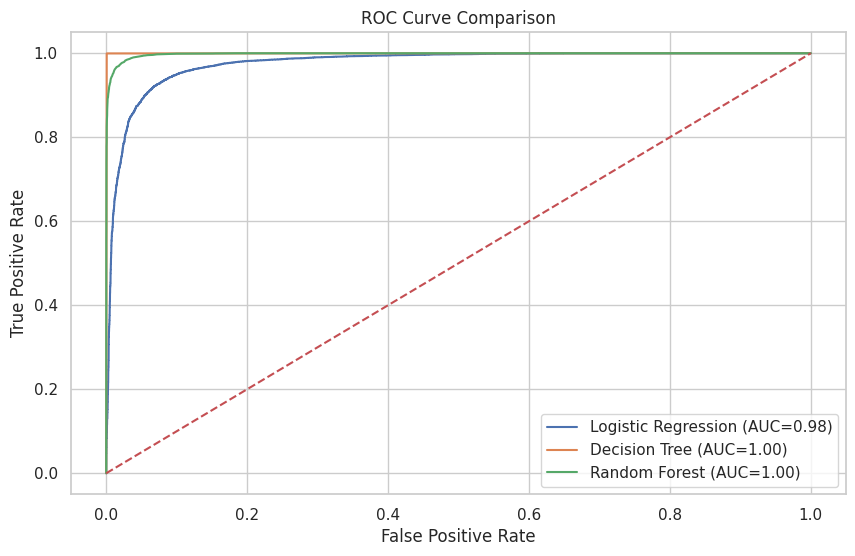


Model Comparison:

                     Accuracy   ROC AUC
Logistic Regression   0.92650  0.976113
Decision Tree         0.99945  0.999451
Random Forest         0.97775  0.998097


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve


# =========================
# Create TARGET (IMPORTANT)
# =========================
df['target'] = (df['sales_amount_gbp'] > df['sales_amount_gbp'].median()).astype(int)

# =========================
# Feature Selection (NO LEAKAGE)
# =========================
X = df.drop(columns=['target', 'sales_amount_gbp', 'order_datetime'])
y = df['target']

# =========================
# Column Types
# =========================
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# =========================
# Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# Preprocessing
# =========================
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# =========================
# Models
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

# =========================
# Training + Evaluation
# =========================
plt.figure(figsize=(10,6))
results = {}

for name, model in models.items():
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results[name] = (acc, roc_auc)
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("ROC AUC:", roc_auc)
    print(classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

# =========================
# Plot ROC Curve
# =========================
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# =========================
# Results Table
# =========================
results_df = pd.DataFrame(results, index=["Accuracy", "ROC AUC"]).T
print("\nModel Comparison:\n")
print(results_df)

## Thank you..pls upvote!!!!!!!